# Investigacao Tecnica Profunda
**Aluno:** Raphaella Souza de Moraes
---

## 1. Pipeline de IA
Implementamos Random Forest para garantir estabilidade em falhas termicas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import shap
import os

path = '../../data/processed/Dataset Tratado.csv'
if not os.path.exists(path): path = 'data/processed/Dataset Tratado.csv'
df = pd.read_csv(path)

features = ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'vibration_levels', 'operational_hours']
X = df[features]
y = df['has_failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

model = RandomForestClassifier(n_estimators=100, max_depth=9, random_state=11)
model.fit(X_train, y_train)

print(f'Validacao Cruzada: {cross_val_score(model, X_train, y_train, cv=5).mean():.4f}')

Validacao Cruzada: 0.9250


## Parte 1: Estresse por Ruido (Foco: Temperatura de Processo)
Simulamos imprecisao no sensor de temperatura com ruidos de 2%, 10% e 18%.

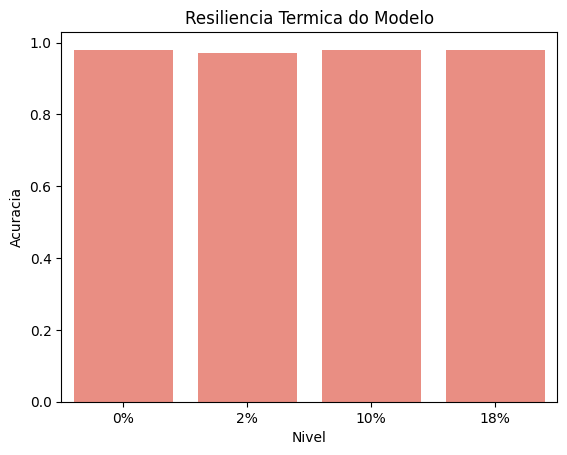

In [2]:
def stress_temp(data, p):
    X_n = data.copy()
    noise = np.random.normal(0, p, X_n['process_temperature_k'].shape) * X_n['process_temperature_k']
    X_n['process_temperature_k'] += noise
    return X_n

results = []
for p in [0, 0.02, 0.10, 0.18]:
    X_s = stress_temp(X_test, p)
    acc = accuracy_score(y_test, model.predict(X_s))
    results.append({'Nivel': f'{int(p*100)}%', 'Acuracia': acc})

sns.barplot(data=pd.DataFrame(results), x='Nivel', y='Acuracia', color='salmon')
plt.title('Resiliencia Termica do Modelo')
plt.show()

## Parte 2: SHAP
Analise de impacto das variaveis de temperatura.

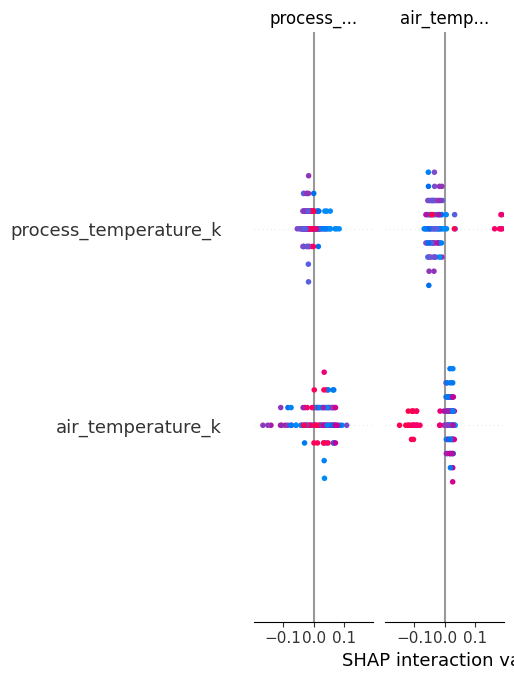

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

## Parte 3: Relatorio de Contingencia

### 3.1 Discussao de Vies
O modelo é mais sensível a variações térmicas no verão (altas temperaturas), podendo gerar alarmes precoces.

### 3.2 Plano de Mitigacao
Utilizar sensores de temperatura de alta precisao e manter a ventilacao industrial limpa para reduzir o ruido termico.